## Carregar pacotes

In [1]:
import pandas as pd
from sklearn.model_selection import ShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.tree import export_graphviz
from matplotlib import pyplot as plt

## Carregar conjunto de dados Iris

In [2]:
dataset_iris = pd.read_csv('../data/Iris.csv')
dataset_iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## Remover a coluna `Id`

In [3]:
dataset_iris.drop(columns=['Id'], inplace=True)
dataset_iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Gráfico da disposição dos exemplos do conjunto Iris em dois eixos

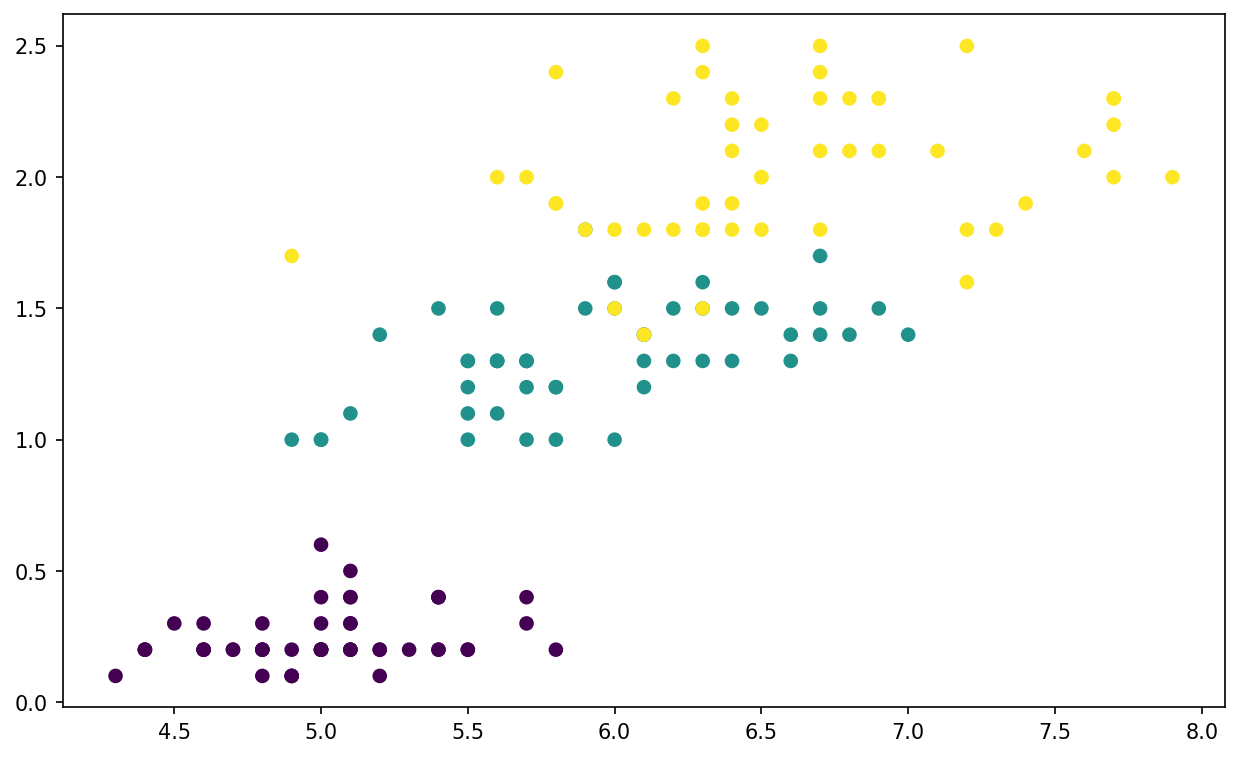

In [4]:
fig, ax = plt.subplots()
ax.scatter(dataset_iris['SepalLengthCm'], dataset_iris['PetalWidthCm'], c=pd.factorize(dataset_iris['Species'])[0])


plt.show()

# Dividir o conjunto de dados em treino e teste
## 80% treino e 20% teste

In [5]:
splitter = ShuffleSplit(n_splits=1, test_size=.20)
strat_splits = []
for train_index, test_index in splitter.split(dataset_iris):
    train_set_n = dataset_iris.iloc[train_index]
    test_set_n = dataset_iris.iloc[test_index]
    strat_splits.append([train_set_n, test_set_n])


train_set = strat_splits[0][0]
test_set = strat_splits[0][1]

print('Total de exemplos')
print(f'Treino: {len(train_set)}')
print(f'Teste: {len(test_set)}')

Total de exemplos
Treino: 120
Teste: 30


## Gráfico da disposição dos exemplos dos conjuntos de treino

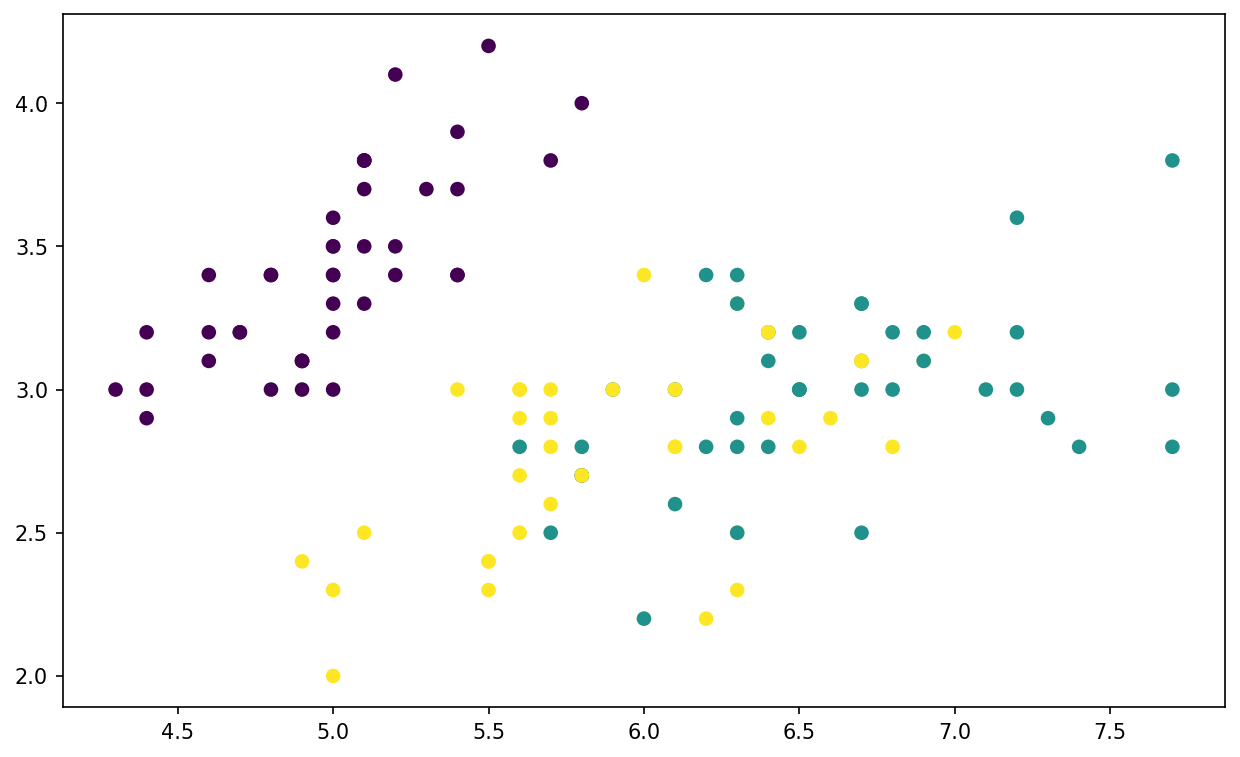

In [6]:
dataset = train_set

fig, ax = plt.subplots()
ax.scatter(dataset['SepalLengthCm'], dataset['SepalWidthCm'], c=[pd.factorize(dataset['Species'])[0]])


plt.show()

## Gráfico da disposição dos exemplos dos conjuntos de teste

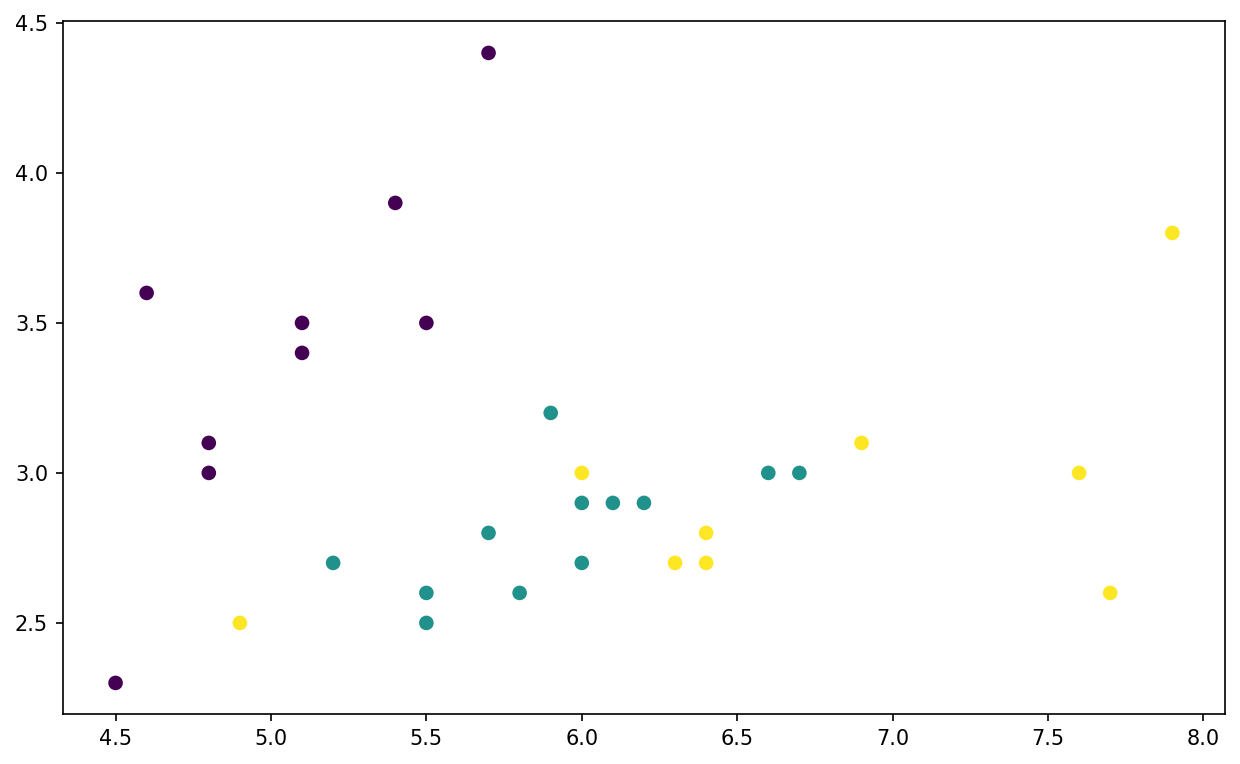

In [7]:
dataset = test_set

fig, ax = plt.subplots()
ax.scatter(dataset['SepalLengthCm'], dataset['SepalWidthCm'], c=pd.factorize(dataset['Species'])[0])


plt.show()

## Subdivide os conjuntos de treino e teste em conjuntos de características e conjunto de rótulos

In [8]:
X_train_set = train_set.drop(columns=['Species'])
y_train_set = train_set['Species'].copy()

X_test_set = test_set.drop(columns=['Species'])
y_test_set = test_set['Species'].copy()

## Define arquitetura da Árvore de Decisão e realiza o treinamento

In [9]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=None)
dtc.fit(X_train_set, y_train_set)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Cria uma representação gráfica do modelo gerado pelo método de árvore de decisão

### A representação é salva em dois arquivos:
### - iris_tree.dot
### - iris_tree.png

In [10]:
export_graphviz(
    dtc,
    out_file='iris_tree.dot',
    feature_names=X_train_set.columns,
    rounded=True,
    filled=True
)

! dot -Tpng iris_tree.dot -o iris_tree.png

## Exibe o arquivo iris_tree.png

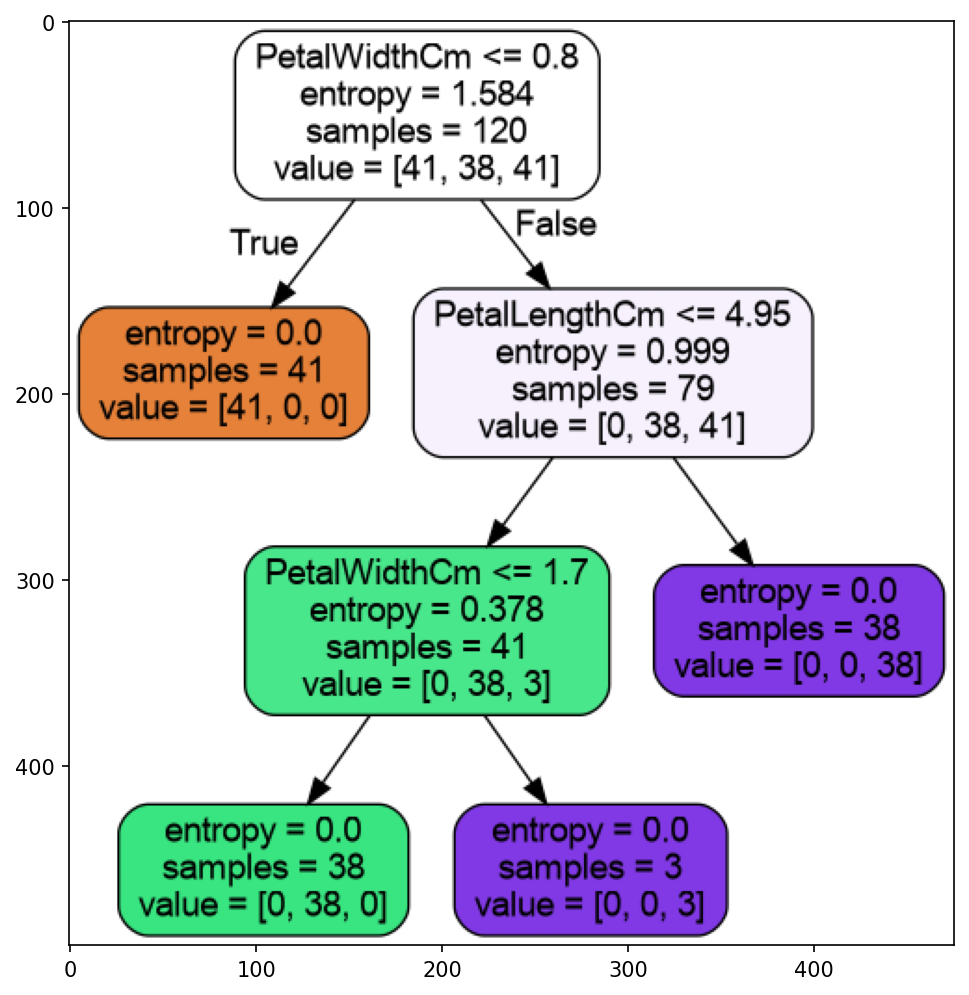

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('iris_tree.png')
plt.figure(figsize=(10, 8))
imgplot = plt.imshow(img)
plt.show()

## Realiza a predição do conjunto de teste e exibe o desempenho

### As métricas de desempenho utilizadas são: acurácia, revocação e precisão

In [12]:
predicts_dtc = dtc.predict(X_test_set)


print(f'Acurácia: {accuracy_score(y_test_set, predicts_dtc)}')
print(f'Revocação: {recall_score(y_test_set, predicts_dtc, average=None)}')
print(f'Precisão: {precision_score(y_test_set, predicts_dtc, average=None)}')

Acurácia: 0.9
Revocação: [1.   0.75 1.  ]
Precisão: [1.   1.   0.75]


<br><br><br><br>

# Exercício

## Altere a estrutura da árvore de decisão utilizada e, para cada configuração, replique pelo menos 3 vezes (gerando novos conjuntos de treino e teste) e indique a menor arquitetura encontrada. 

### Definindo Parametros e funcoes para repitibilidade:

In [16]:
MAX_DEPTHS = (2, 3, 4, 5, None)
N_TESTES = 300

def split(splitter: ShuffleSplit, dataset: pd.DataFrame) -> tuple:
    strat_splits = []
    for train_index, test_index in splitter.split(dataset):
        train_set_n = dataset.iloc[train_index]
        test_set_n = dataset.iloc[test_index]
        strat_splits.append([train_set_n, test_set_n])


    train_set = strat_splits[0][0]
    test_set = strat_splits[0][1]

    return (train_set, test_set)

### Rodando 300 vezes para cada arvore e testando a acuracia

In [18]:
import numpy as np
resultados = np.zeros(len(MAX_DEPTHS))
for n_split in range(N_TESTES):
    train_set, test_set = split(splitter, dataset_iris)
    X_train_set = train_set.drop(columns=['Species'])
    y_train_set = train_set['Species'].copy()

    X_test_set = test_set.drop(columns=['Species'])
    y_test_set = test_set['Species'].copy()

    for i, depth in enumerate(MAX_DEPTHS):
        dtc = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
        dtc.fit(X_train_set, y_train_set)
        predicts_dtc = dtc.predict(X_test_set)
        
        resultados[i] += accuracy_score(y_test_set, predicts_dtc)

resultados /= N_TESTES
pd.Series(resultados, name='Acuracia', index=MAX_DEPTHS)

2.0    0.938778
3.0    0.947778
4.0    0.943889
5.0    0.946222
NaN    0.947222
Name: Acuracia, dtype: float64

Pudemos ver, portanto, que as melhores arvores sao as de tamanho 3,
e nao a arvore sem limite de tamanho